# Train Model

Notebook hasil konversi dari `train_model.py`.


Import library

In [1]:
import pandas as pd, numpy as np, re, pickle, os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay,
                              RocCurveDisplay, roc_auc_score)
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt


In [2]:
df_test = pd.read_csv("judol_test_dataset.csv")
df_train = pd.read_csv("judol_train_dataset.csv")

Preprocess

In [3]:
JUDOL_RE = re.compile(
    r"alex\s*1?s?\s*17|4lexis17|alexis\s*17|a\s*l\s*e\s*x\s*i\s*s\s*1\s*7|"
    r"mandalika\s*77|weton\s*88|pulau\s*777|pulau\s*win|pulauwin|"
    r"sl[o0]t|s\s*l\s*o\s*t|g[a4]c[o0]r|g\s*a\s*c\s*o\s*r|"
    r"max\s*w?in|m4xw1n|maxw1n|maks?\s*win|"
    r"jepe?y?|\bjp\b|ngecuan|cuan\b|depo(sit)?|\bwd\b|withdraw|"
    r"scatter|zeus|olympus|pgsoft|pragmatic|starlight|rungk(ad)?|"
    r"\bbonus\b|\bmenang\b|ketagihan|\bsitus\b|sketer|gampang|"
    r"\blanding\b|\bcair\b|\bgabung\b|\bjoin\b|\bdaftar\b|"
    r"terpercaya|bocoran|bocor\b|modal\s*(kecil|receh)|rezeki\s*mengalir|"
    r"petir\s*x|zeus\s*x|scatter\s*hitam|\b(77|88|777|17)\b",
    re.IGNORECASE
)

NORM = {
    'yg':'yang','dgn':'dengan','gk':'tidak','ga':'tidak','gak':'tidak',
    'nggak':'tidak','ngga':'tidak','krn':'karena','karna':'karena',
    'utk':'untuk','tdk':'tidak','tp':'tapi','lg':'lagi','udh':'sudah',
    'sdh':'sudah','dg':'dengan','sm':'sama','jd':'jadi','aja':'saja',
    'bgt':'banget','emg':'memang','emang':'memang','bs':'bisa','org':'orang',
    'dr':'dari','klo':'kalau','kl':'kalau','sy':'saya','gw':'saya',
    'gue':'saya','lo':'kamu','lu':'kamu','wkwkwk':'tertawa','wkwk':'tertawa',
    'sl0t':'slot','s1ot':'slot','jud1':'judi','b0coran':'bocoran','maxw1n':'maxwin',
    'g4cor':'gacor','g4c0r':'gacor','gac0r':'gacor','4lexis':'alexis',
    'alex1s':'alexis','m4xwin':'maxwin',
}

def normalize_spaced(text):
    def collapse(m): return re.sub(r'[\s._-]','',m.group(0))
    return re.sub(r'(?<!\w)([a-zA-Z](?:[\s._-][a-zA-Z]){2,})(?!\w)', collapse, text)

def preprocess(text):
    if pd.isna(text) or str(text).strip()=="": return ""
    text = str(text).encode('ascii','ignore').decode('ascii').lower()
    text = normalize_spaced(text)
    for s,d in [('0','o'),('1','i'),('3','e'),('4','a'),('5','s')]: text=text.replace(s,d)
    text = re.sub(r'http\S+|www\S+','',text); text = re.sub(r'@\w+|#\w+','',text)
    text = re.sub(r'\d+','',text); text = re.sub(r'[^a-z\s]',' ',text)
    return re.sub(r'\s+',' ',' '.join([NORM.get(w,w) for w in text.split()])).strip()

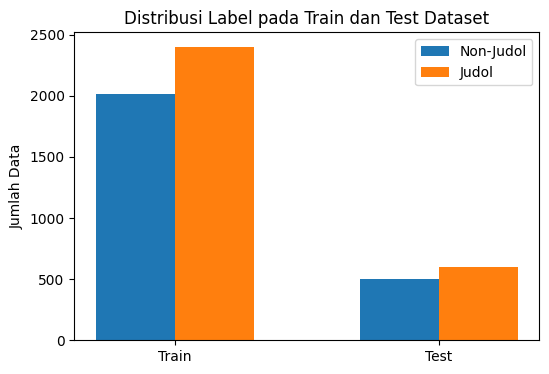

In [4]:
label_mapping = {0: "Non-Judol", 1: "Judol"}

counts_train = (
    df_train["label"]
    .map(label_mapping)
    .value_counts()
    .reindex(["Non-Judol", "Judol"], fill_value=0)
)

counts_test = (
    df_test["label"]
    .map(label_mapping)
    .value_counts()
    .reindex(["Non-Judol", "Judol"], fill_value=0)
)

datasets = ["Train", "Test"]
non_judol = [counts_train["Non-Judol"], counts_test["Non-Judol"]]
judol = [counts_train["Judol"], counts_test["Judol"]]

x = np.arange(len(datasets))
width = 0.3

plt.figure(figsize=(6,4))

plt.bar(x - width/2, non_judol, width, label="Non-Judol")
plt.bar(x + width/2, judol, width, label="Judol")

plt.xticks(x, datasets)
plt.ylabel("Jumlah Data")
plt.title("Distribusi Label pada Train dan Test Dataset")
plt.legend()

plt.show()


In [5]:
train = pd.read_csv('judol_train_dataset.csv')
test  = pd.read_csv('judol_test_dataset.csv')
print(f"Train: {len(train):,} | Test: {len(test):,}\n")
print(f"Train Dataset : \n{df_train["label"].value_counts()}\n")
print(f"Test Dataset : \n{df_test["label"].value_counts()}")

Train: 4,417 | Test: 1,105

Train Dataset : 
label
1    2400
0    2017
Name: count, dtype: int64

Test Dataset : 
label
1    600
0    505
Name: count, dtype: int64


In [6]:
xlsx_file = 'judi_online_comments.xlsx'
if os.path.exists(xlsx_file):
    df_xlsx = pd.read_excel(xlsx_file)
    col = 'komentar' if 'komentar' in df_xlsx.columns else df_xlsx.columns[0]
    rows = []
    for txt in df_xlsx[col].astype(str):
        lbl = 1 if JUDOL_RE.search(txt) else 0
        if lbl==0 and re.search(r'ð[^\s]{4,}.*\d{2}|\d{2}.*ð[^\s]{4,}', txt): lbl=1
        if lbl==0 and re.search(r'[Aa]\s+[Ll]\s+[Ee]\s+[Xx]\s+[Ii]\s+[Ss]\s+\d', txt): lbl=1
        rows.append({'text':txt,'label':lbl})
    df_xlsx_labeled = pd.DataFrame(rows)
    train = pd.concat([train, df_xlsx_labeled], ignore_index=True)
    # print(f"+ XLSX: {len(df_xlsx_labeled)} baris ditambahkan")

train['clean'] = train['text'].apply(preprocess)
test['clean']  = test['text'].apply(preprocess)
train = train[train['clean'].str.len()>0].reset_index(drop=True)
test  = test[test['clean'].str.len()>0].reset_index(drop=True)

tfidf = TfidfVectorizer(max_features=12000, ngram_range=(1,2), min_df=2, sublinear_tf=True)
X_train = tfidf.fit_transform(train['clean']); X_test = tfidf.transform(test['clean'])
y_train, y_test = train['label'], test['label']

models = {
    "Logistic Regression": LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    "SVM":                  LinearSVC(C=1.0, max_iter=2000, random_state=42),
    "Naive Bayes":          MultinomialNB(alpha=0.1),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
eval_results, trained = {}, {}
for name, model in models.items():
    model.fit(X_train, y_train); y_pred = model.predict(X_test)
    eval_results[name] = {
        'accuracy':round(accuracy_score(y_test,y_pred),4),
        'precision':round(precision_score(y_test,y_pred,average='weighted'),4),
        'recall':round(recall_score(y_test,y_pred,average='weighted'),4),
        'f1':round(f1_score(y_test,y_pred,average='weighted'),4),
        'cm':confusion_matrix(y_test,y_pred).tolist(),
    }
    trained[name] = model
    r = eval_results[name]
    print(f"  {name:25} Acc={r['accuracy']*100:.2f}%  F1={r['f1']*100:.2f}%")

best = max(eval_results, key=lambda n: eval_results[n]['f1'])
print(f"\nModel terbaik: {best} (F1={eval_results[best]['f1']*100:.2f}%)")
os.makedirs('model',exist_ok=True)
pickle.dump({'tfidf':tfidf,'models':trained,'eval_results':eval_results,'best_model':best},
            open('model/judol_model.pkl','wb'))


  Logistic Regression       Acc=96.01%  F1=96.01%
  SVM                       Acc=96.46%  F1=96.46%
  Naive Bayes               Acc=89.39%  F1=89.22%
  Random Forest             Acc=96.10%  F1=96.10%

Model terbaik: SVM (F1=96.46%)


In [7]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Judol", "Judol"]
))

              precision    recall  f1-score   support

   Non-Judol       0.96      0.96      0.96       505
       Judol       0.96      0.96      0.96       598

    accuracy                           0.96      1103
   macro avg       0.96      0.96      0.96      1103
weighted avg       0.96      0.96      0.96      1103



ROC-AUC Score & ROC Curve

ROC-AUC: 0.9899036391933508


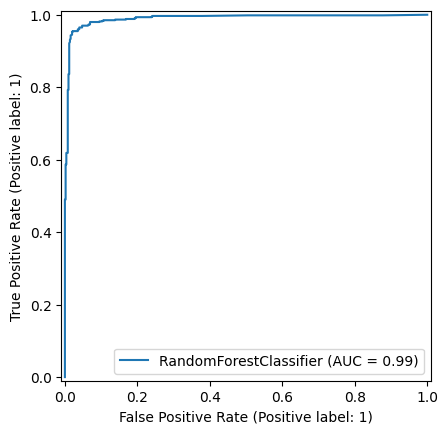

In [8]:
y_score = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_score)

print("ROC-AUC:", auc)

RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.show()

Cross Validation

In [9]:
scores = cross_val_score(
    trained[best],
    X_train,
    y_train,
    cv=5,
    scoring='f1_weighted'
)

for i, score in enumerate(scores, start=1):
    print(f"Fold {i}: {score:.4f}")
print(f'Mean F1 Score: {scores.mean():.4f}')
print(f'Standard Deviation: {scores.std():.4f}')

Fold 1: 0.9527
Fold 2: 0.9613
Fold 3: 0.9667
Fold 4: 0.9591
Fold 5: 0.8411
Mean F1 Score: 0.9362
Standard Deviation: 0.0478


Cek Kenapa Fold 5 Rendah Drpd Fold Lain

In [17]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):

    X_tr = X_train[train_idx]
    X_val = X_train[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    f1 = f1_score(y_val, y_pred, average='weighted')

    print(f"Fold {fold}: {f1:.4f}")

    if fold == 5:
        fold5_idx = val_idx
        fold5_pred = y_pred
        fold5_true = y_val

fold5_df = train.iloc[fold5_idx].copy()
fold5_df["actual"] = fold5_true.values
fold5_df["predicted"] = fold5_pred
print(fold5_df["actual"].value_counts())

fn = fold5_df[
    (fold5_df.actual == 1) &
    (fold5_df.predicted == 0)
]

print(fn[["text"]].head(10))
fp = fold5_df[
    (fold5_df.actual == 0) &
    (fold5_df.predicted == 1)
]

print(fp[["text"]].head(10))

duplicates = train.duplicated(subset=["clean"]).sum()
print(duplicates)
train_text = set(train.iloc[train_idx]["clean"])
val_text = set(train.iloc[val_idx]["clean"])

print(len(train_text & val_text))

cm = confusion_matrix(y_val, y_pred)
print(cm)

Fold 1: 0.9442
Fold 2: 0.9420
Fold 3: 0.9453
Fold 4: 0.9624
Fold 5: 0.9484
actual
1    505
0    425
Name: count, dtype: int64
                                                   text
637                   @݊ꪀᝯ𝑒𝑠𝑠♔🍼 @ShaNia24  korban slot🤣
701    Slot menangnya sekali tapi deponya berkali kali😂
711                                        slot lageee🗿
824   gedabrus🤣 coba ke Jateng khususnya kota "S"......
825   @Ayu Lovina245 @Yuki no hana\ndeloken talah sa...
902   Terima kasih pak kami sebagi pejudi sangat ter...
1064                    ngespin Moonlight habis brp bg?
1520                 makin loba we meren tukang slot th
1664                               judionlen meresahkan
1736                                      😂 virus SLoT.
                                                   text
308   itu akun2 yang promo judi online diblokir saja...
405                                     info link gacor
440                                         woy ra judi
920                       ingat ap

FN, masih lolos + typo + no vocabulary

FP, konteks judol salah

FN & FP

In [12]:
# misclassified = test.copy()
# misclassified["pred"] = y_pred

# fp = misclassified[
#     (misclassified.label == 0) &
#     (misclassified.pred == 1)
# ]

# fn = misclassified[
#     (misclassified.label == 1) &
#     (misclassified.pred == 0)
# ]

# print(f"False Positives: {(fp).head(10)}\n")
# print(f"False Negatives: {(fn).head(10)}")


F1-Score Plot

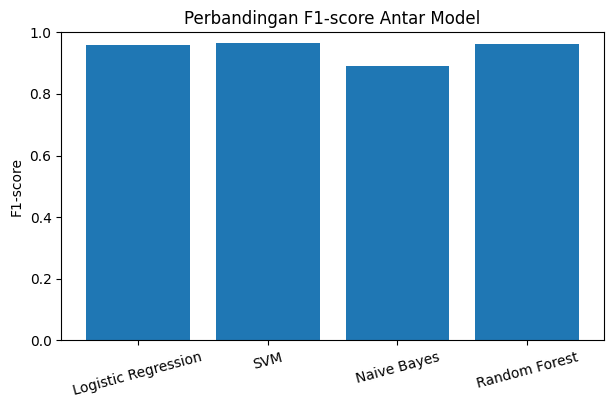

In [13]:
model_names = list(eval_results.keys())
f1_scores = [eval_results[m]['f1'] for m in model_names]

plt.figure(figsize=(7,4))
plt.bar(model_names, f1_scores)
plt.ylabel("F1-score")
plt.title("Perbandingan F1-score Antar Model")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

Accuracy Plot

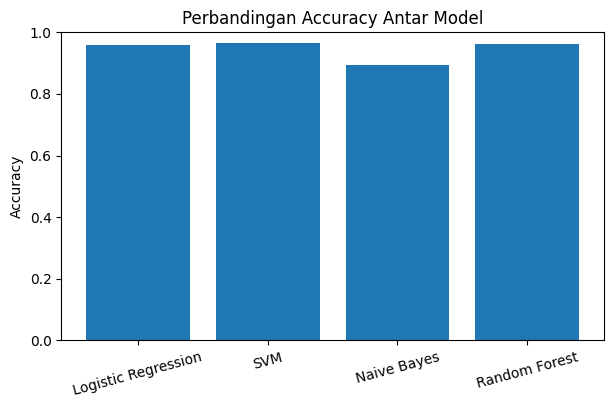

In [14]:
acc_scores = [eval_results[m]['accuracy'] for m in model_names]

plt.figure(figsize=(7,4))
plt.bar(model_names, acc_scores)
plt.ylabel("Accuracy")
plt.title("Perbandingan Accuracy Antar Model")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.show()

best_model = trained[best]

Confusion Matrix Plot

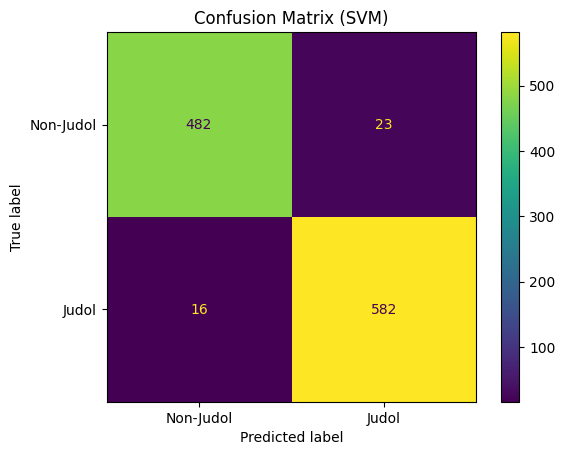

In [15]:

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["Non-Judol", "Judol"]
)

plt.title(f"Confusion Matrix ({best})")
plt.show()